# Randomized Search Optimization
### Hands-on Notebook

**Learning Objectives**
1. Execute **Randomized Search** for efficiency
2. Compare **tuning techniques** for peak performance

---
A clinic wants to predict appointment no-shows using a Random Forest, tuned over three hyperparameters. We'll run Grid Search and Randomized Search side by side on the identical data and compare their cost and quality directly.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

np.random.seed(12)


## 1. The patient no-show dataset


In [2]:
n = 400
lead_time_days = np.random.uniform(0, 60, n)
age = np.random.uniform(18, 80, n)
prior_noshows = np.random.poisson(0.5, n)
distance_km = np.random.uniform(0, 40, n)
sms_reminder = np.random.binomial(1, 0.5, n)
noise1 = np.random.uniform(0, 100, n)

z = 0.04*lead_time_days + 0.3*prior_noshows + 0.03*distance_km - 1.2*sms_reminder - 0.01*age - 1.0
prob_noshow = 1 / (1 + np.exp(-z))
noshow = (np.random.rand(n) < prob_noshow).astype(int)

df = pd.DataFrame({
    "lead_time_days": lead_time_days, "age": age, "prior_noshows": prior_noshows,
    "distance_km": distance_km, "sms_reminder": sms_reminder, "noise1": noise1, "noshow": noshow,
})
X, y = df.drop(columns="noshow").values, df["noshow"].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print(f"{n} appointments, no-show rate: {y.mean():.2f}")


400 appointments, no-show rate: 0.50


## 2. The search space

Three hyperparameters, each with several candidate values.


In [3]:
param_grid = {
    "n_estimators": [50, 100, 150],
    "max_depth": [3, 5, 7, None],
    "min_samples_leaf": [1, 2, 4, 8],
}
total_combos = 3 * 4 * 4
print(f"Total grid combinations: {total_combos}")
print(f"Total model fits with 5-fold CV: {total_combos * 5}")


Total grid combinations: 48
Total model fits with 5-fold CV: 240


## 3. Grid Search — the exhaustive baseline


In [4]:
grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5)
grid.fit(X_train, y_train)

grid_test_acc = accuracy_score(y_test, grid.best_estimator_.predict(X_test))
print("Grid best params:", grid.best_params_)
print(f"Grid best CV score: {grid.best_score_:.3f}")
print(f"Grid test accuracy: {grid_test_acc:.2f}")


Grid best params: {'max_depth': None, 'min_samples_leaf': 8, 'n_estimators': 100}
Grid best CV score: 0.683
Grid test accuracy: 0.56


**Checkpoint:** this should match the slide — best CV score ≈ 0.683, test accuracy ≈ 0.56.


## 4. Randomized Search — sampling instead of exhausting

`RandomizedSearchCV` takes the same `param_grid` but only evaluates `n_iter` randomly sampled combinations.


In [5]:
random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42), param_grid, n_iter=12, cv=5, random_state=42
)
random_search.fit(X_train, y_train)

random_test_acc = accuracy_score(y_test, random_search.best_estimator_.predict(X_test))
print("Random best params:", random_search.best_params_)
print(f"Random best CV score: {random_search.best_score_:.3f}")
print(f"Random test accuracy: {random_test_acc:.2f}")
print(f"Total model fits: {12 * 5}")


Random best params: {'n_estimators': 100, 'min_samples_leaf': 4, 'max_depth': None}
Random best CV score: 0.680
Random test accuracy: 0.57
Total model fits: 60


**Checkpoint:** this should match the slide — best CV score ≈ 0.680, test accuracy ≈ 0.57, using only 60 fits instead of 240.


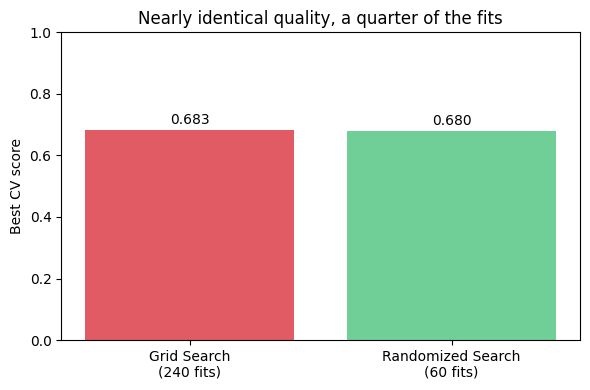

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
methods = ["Grid Search\n(240 fits)", "Randomized Search\n(60 fits)"]
scores = [grid.best_score_, random_search.best_score_]
ax.bar(methods, scores, color=["#E15B64", "#6FCF97"])
ax.set_ylabel("Best CV score")
ax.set_ylim(0, 1)
ax.set_title("Nearly identical quality, a quarter of the fits")
for i, s in enumerate(scores):
    ax.text(i, s + 0.02, f"{s:.3f}", ha="center")
plt.tight_layout(); plt.show()


## 5. Exercises


**Exercise 1.** Rerun Randomized Search with `n_iter=24` (half the grid instead of a quarter). Does the best CV score get closer to Grid Search's 0.683, and by how much?


In [7]:
# TODO



<details><summary>Solution</summary>

```python
random_search_24 = RandomizedSearchCV(
    RandomForestClassifier(random_state=42), param_grid, n_iter=24, cv=5, random_state=42
)
random_search_24.fit(X_train, y_train)
print(random_search_24.best_score_)
```
With more samples, the result typically edges closer to (or matches) the Grid Search score — there's a real, if often small, trade-off between `n_iter` and how close you get to the true best-in-grid configuration.
</details>


**Exercise 2.** Compute what fraction of the full 48-configuration grid `n_iter=12` actually explored, as a percentage.


In [8]:
# TODO



<details><summary>Solution</summary>

```python
print(12 / 48 * 100)  # 25.0
```
</details>


**Exercise 3.** Using `grid.cv_results_`, find how many of the 48 tested configurations scored within 0.01 of the best CV score. What does that number suggest about how "special" the single best configuration really is?


In [9]:
# TODO



<details><summary>Solution</summary>

```python
scores = pd.Series(grid.cv_results_["mean_test_score"])
near_best = (scores >= grid.best_score_ - 0.01).sum()
print(near_best, "of", len(scores), "configurations scored within 0.01 of the best")
```
Usually several configurations land within a hair of the top score — the "best" configuration in a grid is rarely a unique standout, which is part of why sampling a subset (as Randomized Search does) tends to still find a genuinely competitive result.
</details>


## 6. Recap

- **Randomized Search** samples a fixed number (`n_iter`) of random hyperparameter combinations instead of testing every one, directly controlling how many model fits the search costs.
- On this dataset, sampling 25% of the grid (12 of 48 configurations, 60 of 240 fits) found a CV score within 0.003 of the full exhaustive search — and matched it on held-out test accuracy.
- **Comparing tuning techniques**: Grid Search suits small, cheap search spaces where exhaustiveness is affordable; Randomized Search suits larger ones, where a near-best answer for a fraction of the cost usually beats a guaranteed-best answer that takes far longer to reach.
